In [3]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Union, Tuple, List
from utils import ImageBatchGenerator, ManualConvLayer,Flatten,SigmoidAct,TanhAct
from PIL import Image

In [4]:
dogs_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\dog"
cats_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\cat"
img_batch = ImageBatchGenerator({"dog":dogs_path, "cat":cats_path},batch_size=8,network_input_size=(100,100))
conv_layer = ManualConvLayer(kernel_shape=(3,3),kernel_count=5,padding=1,stride=2)
output = conv_layer.forward(img_batch.batch_matrix)
output.shape 

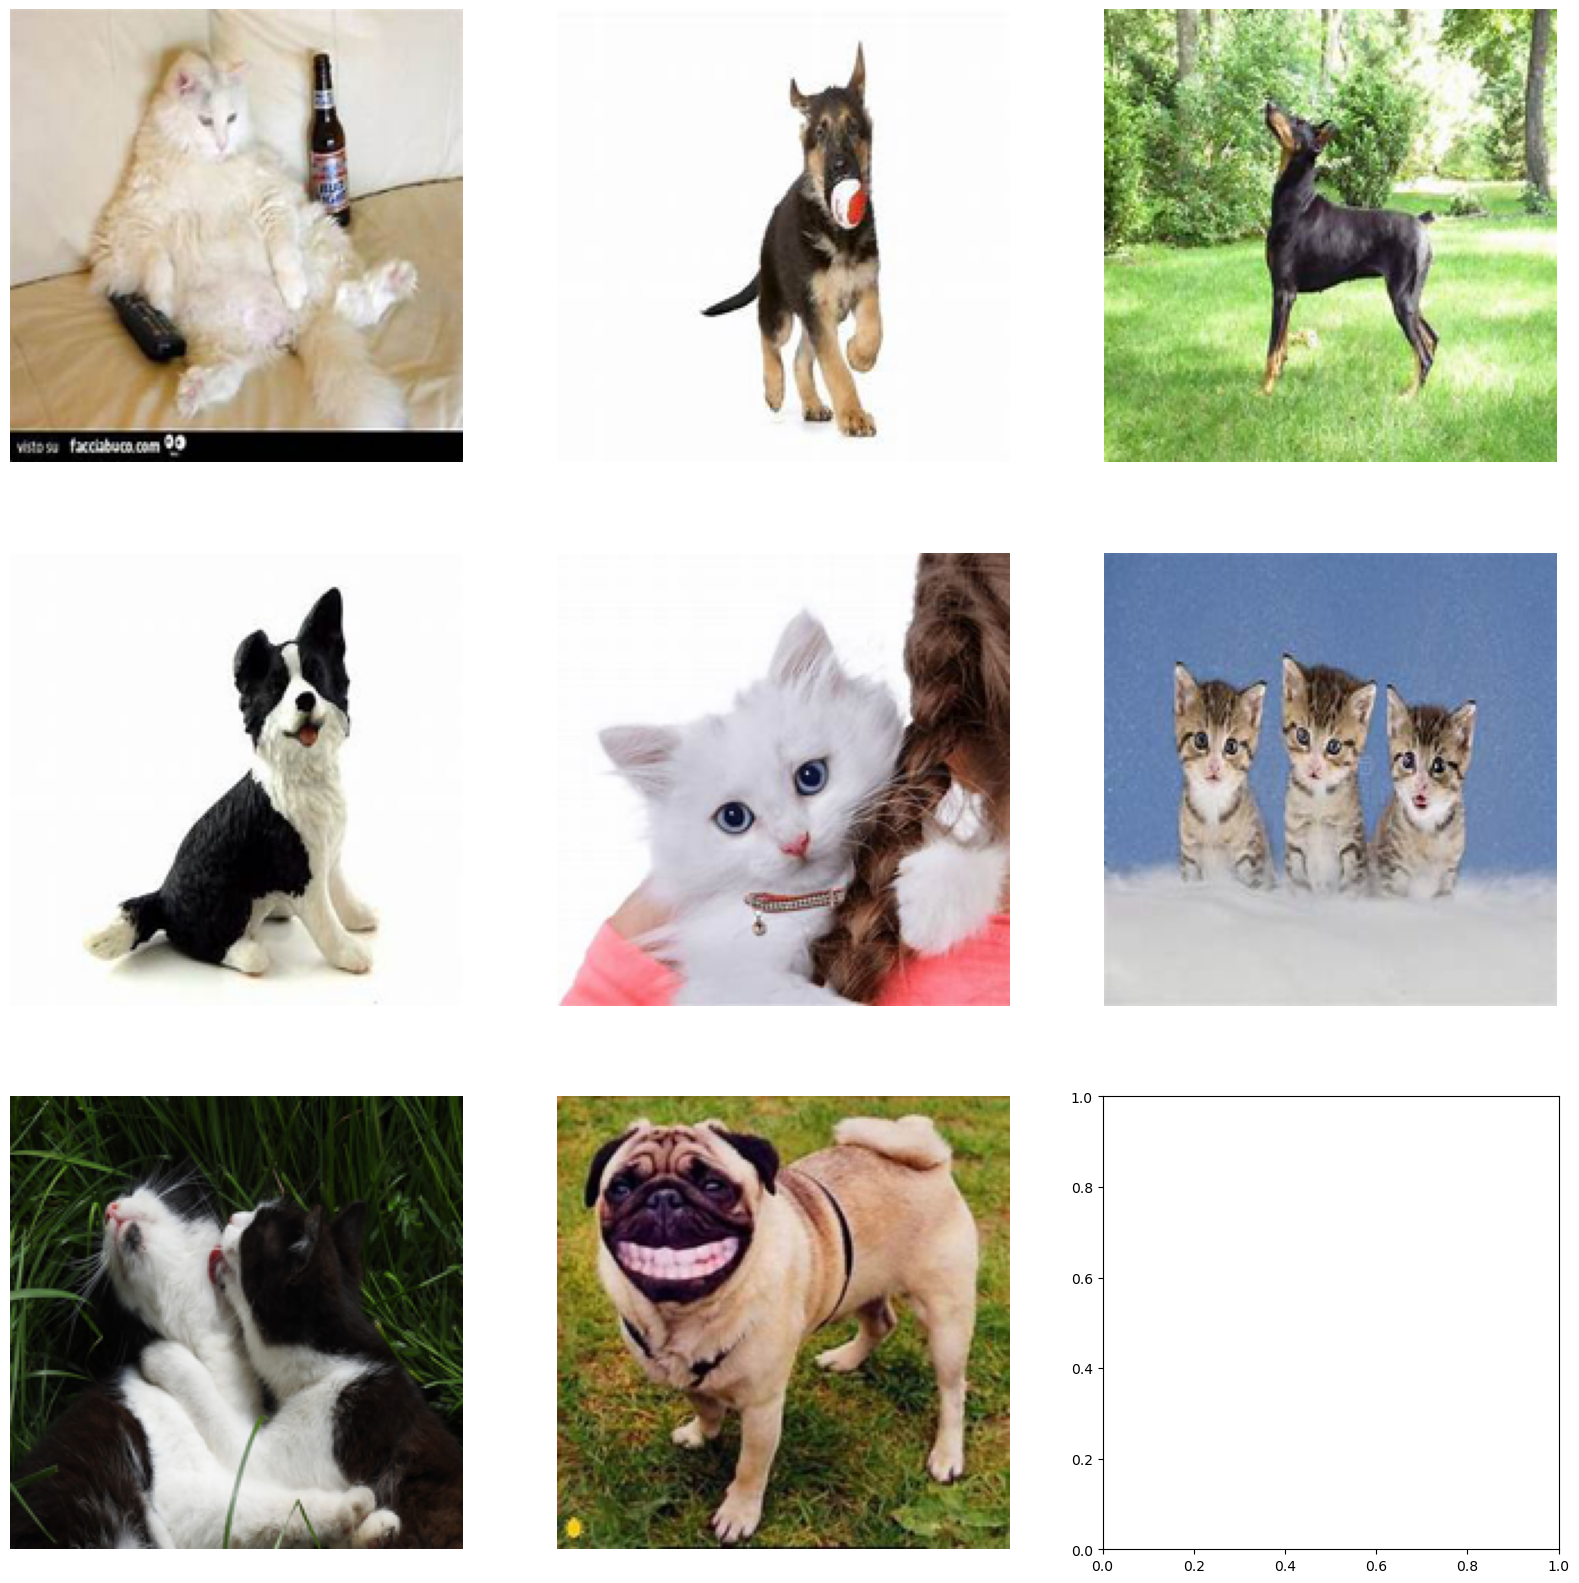

In [67]:
img_batch.visualize_batch()

#### now lets test out our sigmoidAct and TanhAct


In [2]:
X = np.array([2, 3, 4])
# S(X)	0.8807970779779563
# S'(X)	0.1049935854034503 sigmoid prime(X)
sigmoid_act = SigmoidAct()
result = sigmoid_act.forward(np.array([2, 3, 4]))
result

array([0.88079708, 0.95257413, 0.98201379])

In [3]:
sigmoid_act.backward(1)

array([0.10499359, 0.04517666, 0.01766271])

In [4]:
print(sigmoid_act.backward(0.2))
print(result*(1-result)*0.2)

[0.02099872 0.00903533 0.00353254]
[0.02099872 0.00903533 0.00353254]


In [5]:
tanh_act = TanhAct()
res = tanh_act.forward(X)
res # expected :[0.964027580076,0.995054753687,0.999329299739]


array([0.96402758, 0.99505475, 0.9993293 ])

In [7]:
print(tanh_act.backward(0.2))
print((1-res**2)*0.2)

[0.01413016 0.00197321 0.00026819]
[0.01413016 0.00197321 0.00026819]


---
---

### now we will implement backprop. of pooling layer
- again no derivatives needed, we just need to multiply the outer deriv with the mask


<img src="..\..\data\markdown_images\pooling_backprop.png" width="600" height="400" alt="Image description">


In [ ]:
"""slice_1 = np.array([[0,1,2],[2,3,5],[4,7,10]])
val = slice_1.max()
a,b = np.where(slice_1 == val)
a,b = int(a),int(b)"""

In [7]:
class PoolingLayer:
    # pooling layer doesnt have a learnable parameter.
    def __init__(self,method:str=None,kernel_shape:Tuple[int,int]=(3,3),stride:int=1) -> None:
        methods = {
            "average":np.mean,
            "max":np.max,
            "min":np.min
        }
        self.method = methods.get(method,np.max)
        self.kernel_shape = kernel_shape
        self.stride = stride

    def forward(self, img_batch:np.ndarray) -> np.ndarray:
        self.img_x, self.img_y, self.img_channels, self.batch_size = img_batch.shape
        print("batch_size",self.batch_size)
        print("img_channels",self.img_channels)
        self.inputs = img_batch
        self.output_x = (self.img_x - self.kernel_shape[0]) // self.stride + 1
        self.output_y = (self.img_y - self.kernel_shape[1]) // self.stride + 1
        self.output = np.zeros((self.output_x, self.output_y, self.img_channels, self.batch_size)) # no need for kernel count since pooling is done per channel
        
        self.values_of_interest = np.zeros((self.kernel_shape[0]*self.kernel_shape[1],2,self.output_x*self.output_y,self.img_channels,self.batch_size))
        self.n_values_of_interest = np.zeros((self.output_x*self.output_y,self.img_channels,self.batch_size))


        # and not added over channels
        padded_image = img_batch
        self.mask = padded_image.copy()
        for i in range(self.batch_size):

            current_padded_img = padded_image[:, :, :, i]
            for c in range(self.img_channels):
                slice_i = 0
                for y in range(self.output_y):
                    for x in range(self.output_x): # this inner loop actually defines a complete slice, and
                        # for each channel-feature map, we expect self.output_x*self.output_y slices.
                        slice_i += 1
                        x_start = x * self.stride
                        x_end = x_start + self.kernel_shape[0]
                        y_start = y*self.stride
                        y_end = y_start + self.kernel_shape[1]
                        current_window = current_padded_img[x_start:x_end, y_start:y_end, c]
                        val = float(self.method(current_window))
                        self.output[x, y, c, i] = val

                        val_x,val_y = np.where(current_window == val)
                        # we can have more than one value of interest
                        for ii, (vx,vy) in enumerate(zip(val_x,val_y)):
                            self.values_of_interest[ii,0,slice_i-1,c,i] = vx
                            self.values_of_interest[ii,1,slice_i-1,c,i] = vy
                        self.n_values_of_interest[slice_i-1,c,i] = ii+1 # for backpropagation

                        # then we have to keep track of the indices that contributed to the max value
                        # for backpropagation
                        self.mask[x_start + val_x, y_start + val_y, c, i] = 1
                if c == 0:
                    print(f"for channel {c}, the max slice_i is {slice_i}")
            print(f"FINISHED element {i}/{self.batch_size}")

        return self.output
    
    def backward(self, outer_deriv:np.ndarray) -> np.ndarray:
        x_outer,y_outer,n_channels,batch_size = outer_deriv.shape
        self.dinputs = np.zeros_like(self.inputs)

        for i in range(batch_size):
            for c in range(n_channels):
                slice_i = 0
                for y in range(y_outer):
                    for x in range(x_outer):
                        slice_i += 1
                        x_start = x * self.stride
                        y_start = y*self.stride

                        # how many maxima(actually value of interest determined by the pooling method)
                        # exists in this slice  = n_values
                        n_values = int(self.n_values_of_interest[slice_i-1,c,i])
                        for idx in range(n_values):
                            # then iterate thru it and for modify outer_deriv accordingly
                            val_x = int(self.values_of_interest[idx,0,slice_i-1,c,i])
                            val_y = int(self.values_of_interest[idx,1,slice_i-1,c,i])
                            self.dinputs[x_start+val_x,y_start+val_y,c,i] = outer_deriv[x,y,c,i]

        return self.dinputs

In [55]:
max_pool = PoolingLayer("max")
max_pool.forward(output)
print("total_slices expected:",max_pool.output_x*max_pool.output_y)

batch_size 8
img_channels 5
for channel 0, the max slice_i is 9604
FINISHED element 0/8
for channel 0, the max slice_i is 9604
FINISHED element 1/8
for channel 0, the max slice_i is 9604
FINISHED element 2/8
for channel 0, the max slice_i is 9604
FINISHED element 3/8
for channel 0, the max slice_i is 9604
FINISHED element 4/8
for channel 0, the max slice_i is 9604
FINISHED element 5/8
for channel 0, the max slice_i is 9604
FINISHED element 6/8
for channel 0, the max slice_i is 9604
FINISHED element 7/8
total_slices expected: 9604


Text(0.5, 1.0, 'mask')

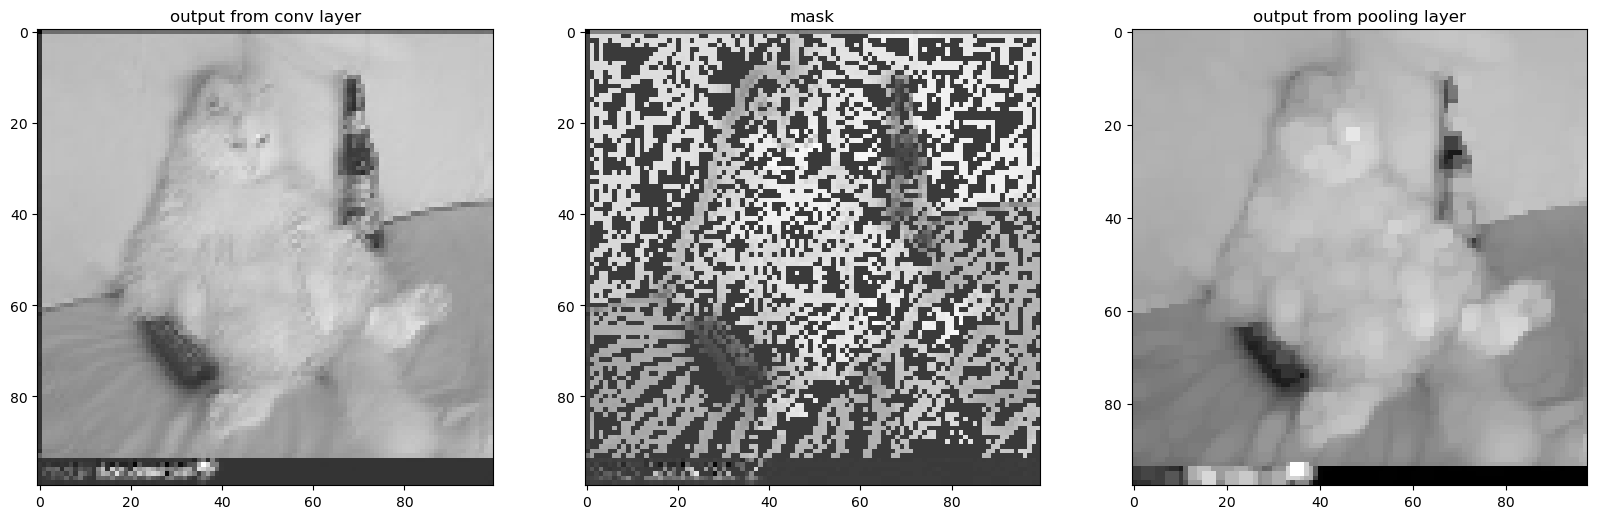

In [56]:
# now lets visualize the output from conv:output, pooled output max_pool.output and the mask
fig, axs = plt.subplots(1,3 ,figsize=(20, 20))

axs[0].imshow(output[:,:,0,0],cmap="gray")
axs[0].set_title("output from conv layer")
axs[2].imshow(max_pool.output[:,:,0,0],cmap="gray")
axs[2].set_title("output from pooling layer")
axs[1].imshow(max_pool.mask[:,:,0,0],cmap="gray")
axs[1].set_title("mask")

Text(0.5, 1.0, 'mask')

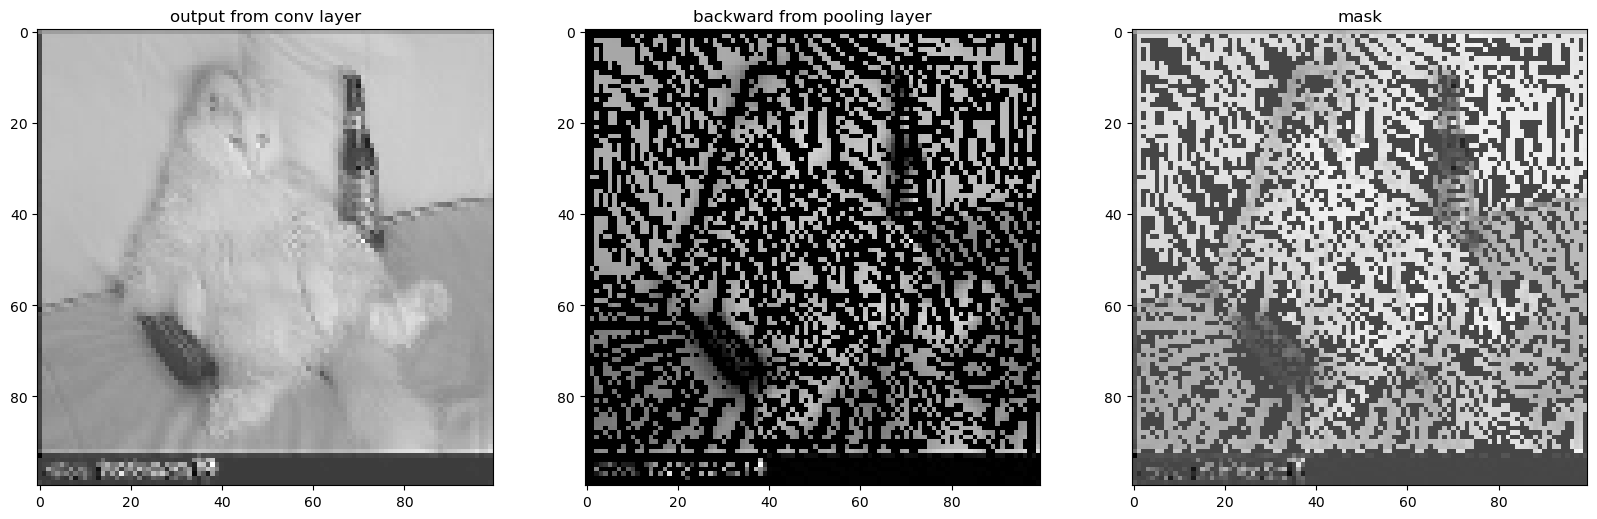

In [65]:
reconstructed = max_pool.backward(max_pool.output)
fig, axs = plt.subplots(1,3 ,figsize=(20, 20))
axs[1].imshow(reconstructed[:,:,2,0],cmap="gray")
axs[1].set_title("backward from pooling layer")
axs[0].imshow(output[:,:,2,0],cmap="gray")
axs[0].set_title("output from conv layer")
# lets plot the mask as well
axs[2].imshow(max_pool.mask[:,:,2,0],cmap="gray")
axs[2].set_title("mask")

### so our backprop implemenetation ensures highlighting only the masked coordinated values of the gradients coming from lower layers , and zeroing out the rest

----
----


### now lets implement backward method of manual conv layer

In [31]:

class ManualConvLayer:
    def __init__(self,kernel_shape=(3,3),kernel_count:int=5,stride:int=1,padding:int=0) -> None:
        self.kernel_x , self.kernel_y = kernel_shape
        self.kernel_count = kernel_count # represents the number of output feature maps (or channels)
        self.stride = stride
        self.padding = padding
        # here kernels and their corresponding biases are learned parameters
        # He initialization
        fan_in = self.kernel_x * self.kernel_y * kernel_count
        stddev = np.sqrt(2 / fan_in)
        self.weights = np.random.randn(self.kernel_x, self.kernel_y,self.kernel_count) * stddev
        self.biases = np.zeros((1,self.kernel_count))

    def forward(self,img_batch:np.ndarray) -> np.ndarray:
        img_x,img_y,img_channels,batch_size = img_batch.shape

        self.output_x = (img_x - self.kernel_x + 2 * self.padding) // self.stride + 1
        self.output_y = (img_y - self.kernel_y + 2 * self.padding) // self.stride + 1
        self.output =  np.zeros((self.output_x, self.output_y, img_channels, self.kernel_count, batch_size))
        self.weights = np.nan_to_num(self.weights)
        self.biases = np.nan_to_num(self.biases)
        self.padded_image = np.zeros((img_x + 2 * self.padding, img_y + 2 * self.padding, img_channels, self.kernel_count, batch_size))
        
        # padd all batch images for each kernel, think it of as parallel strings.
        # FIXME: The padding is applied for each kernel separately, which is unnecessary and inefficient. Padding should be applied once to the input.
        for k in range(self.kernel_count):
            self.padded_image[self.padding:img_x + self.padding, self.padding:img_y + self.padding, :, k, :] = img_batch

        # TODO: vectorize - parallelize this loop
        for i in range(batch_size):
            padded_img = self.padded_image[:, :, :, :, i]
            for c in range(img_channels):
                for k in range(self.kernel_count):
                    for y in range(self.output_y):
                        for x in range(self.output_x):
                            # adjusting the current sliding window
                            x_start = x * self.stride
                            x_end = x_start + self.kernel_x
                            y_start = y*self.stride
                            y_end = y_start + self.kernel_y
                            current_window = padded_img[x_start:x_end, y_start:y_end, c, k]
                            self.output[x, y, c, k, i] = np.sum(np.multiply(current_window, self.weights[:,:,k])) + self.biases[0,k].astype("float64")

        # now we need to sum the convolutions over all channels: axis=2
        # Summing across the input channels (axis=2) effectively combines the contributions from each input channel for a given kernel and spatial location.
        self.output = self.output.sum(axis=2)
        # now lets save the input as well (for backpropagation)
        self.input = img_batch
        return self.output
    

    def backward(self,outer_deriv:np.ndarray)->np.ndarray:
        
        dbiases = np.zeros_like(self.biases)
        dweights = np.zeros_like(self.weights)
        x_pad,y_pad,c_pad,k_pad,i_pad = self.padded_image.shape
        dinputs = np.zeros((x_pad,y_pad,c_pad,i_pad)) # we need to go from padded image -> (x,y,c,i) so we need to remove kernel dim.
        x_outer,y_outer= outer_deriv.shape[0],outer_deriv.shape[1]
        padded_img = self.padded_image[:,:,:,0,:] # to remove kernel dim.
        
        for i in range(i_pad):
            current_padded_img = padded_img[:, :, :, i]
            for c in range(c_pad):
                for k in range(self.kernel_count):
                    for y in range(y_outer):
                        for x in range(x_outer):
                            # adjusting the current sliding window
                            x_start = x * self.stride
                            x_end = x_start + self.kernel_x
                            y_start = y*self.stride
                            y_end = y_start + self.kernel_y
                            current_window = current_padded_img[x_start:x_end, y_start:y_end, c]
                            dinputs[x_start:x_end, y_start:y_end, c, i] += self.weights[:,:,k]*outer_deriv[x,y,k,i] 
                            dweights[:,:,k] += current_window * outer_deriv[x,y,k,i] # accumulate 
                    # after convolving this kernel, calculate/accumulate the differential term for bias
                    dbiases[0,k] += np.sum(np.sum(outer_deriv[:,:,k,i],axis=0),axis=0)
        dinputs = dinputs[self.padding:x_pad-self.padding,self.padding:y_pad-self.padding,:,:]
        return dinputs
        

In [5]:
w = np.array([[1,2,3],[3,5,7]])
np.flip(w)

array([[7, 5, 3],
       [3, 2, 1]])

In [32]:
## now lets run 2 forward passes
conv_layer1 = ManualConvLayer(kernel_shape=(3,3),kernel_count=3)
output1 = conv_layer1.forward(img_batch.batch_matrix)
max_pool_1 = PoolingLayer("max")
output2 = max_pool_1.forward(output1)
conv_layer2 = ManualConvLayer(kernel_shape=(3,3),kernel_count=5)
output3 = conv_layer2.forward(output2)
max_pool_2 = PoolingLayer("max")
output4 = max_pool_2.forward(output3)
output4.shape


batch_size 8
img_channels 3
for channel 0, the max slice_i is 9216
FINISHED element 0/8
for channel 0, the max slice_i is 9216
FINISHED element 1/8
for channel 0, the max slice_i is 9216
FINISHED element 2/8
for channel 0, the max slice_i is 9216
FINISHED element 3/8
for channel 0, the max slice_i is 9216
FINISHED element 4/8
for channel 0, the max slice_i is 9216
FINISHED element 5/8
for channel 0, the max slice_i is 9216
FINISHED element 6/8
for channel 0, the max slice_i is 9216
FINISHED element 7/8
batch_size 8
img_channels 5
for channel 0, the max slice_i is 8464
FINISHED element 0/8
for channel 0, the max slice_i is 8464
FINISHED element 1/8
for channel 0, the max slice_i is 8464
FINISHED element 2/8
for channel 0, the max slice_i is 8464
FINISHED element 3/8
for channel 0, the max slice_i is 8464
FINISHED element 4/8
for channel 0, the max slice_i is 8464
FINISHED element 5/8
for channel 0, the max slice_i is 8464
FINISHED element 6/8
for channel 0, the max slice_i is 8464
FINIS

(92, 92, 5, 8)

Text(0.5, 1.0, 'output from pooling layer 2')

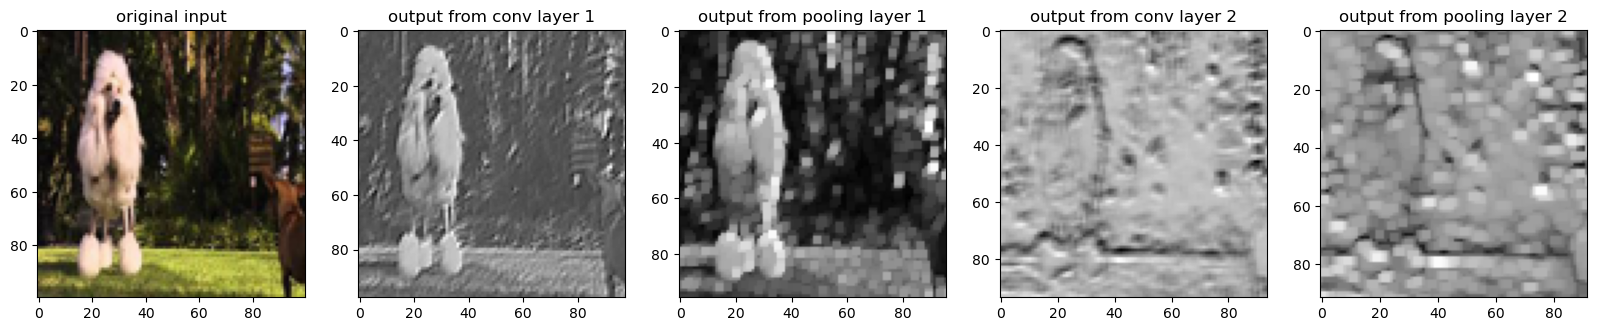

In [26]:
# visualize the output
fig, axs = plt.subplots(1,5 ,figsize=(20, 20))
axs[0].imshow(img_batch.batch_matrix[:,:,:,0],cmap="gray")
axs[0].set_title("original input")
axs[1].imshow(output1[:,:,0,0],cmap="gray")
axs[1].set_title("output from conv layer 1")
axs[2].imshow(output2[:,:,0,0],cmap="gray")
axs[2].set_title("output from pooling layer 1")
axs[3].imshow(output3[:,:,0,0],cmap="gray")
axs[3].set_title("output from conv layer 2")
axs[4].imshow(output4[:,:,0,0],cmap="gray")
axs[4].set_title("output from pooling layer 2")


In [33]:
## now lets run backward pass
back1 = max_pool_2.backward(output4)
back2 = conv_layer2.backward(back1)
back3 = max_pool_1.backward(back2)
back4 = conv_layer1.backward(back3)



In [38]:
back4.shape, img_batch.batch_matrix.shape

((100, 100, 3, 8), (100, 100, 3, 8))

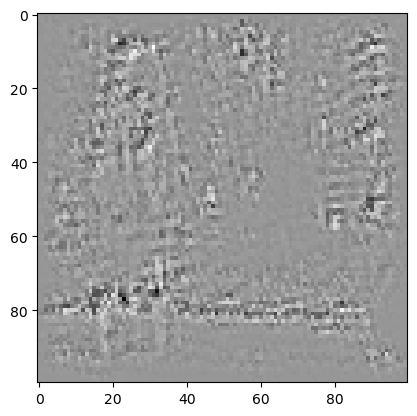

In [37]:
plt.imshow(back4[:,:,0,0],cmap="gray")